In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("athlete_events.csv")
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
data.shape

(271116, 15)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [5]:
data.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [6]:
data['Medal']=data['Medal'].fillna('no medal')

In [7]:
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,no medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,no medal
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,no medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,no medal


In [8]:
data.isnull().sum()

ID            0
Name          0
Sex           0
Age        9474
Height    60171
Weight    62875
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal         0
dtype: int64

In [9]:
data['Height']=data['Height'].fillna(data.groupby(['Sport','Sex'])['Height'].transform("mean"))

In [10]:
data['Height'].head()

0    180.000000
1    170.000000
2    177.480339
3    182.480000
4    185.000000
Name: Height, dtype: float64

In [11]:
data['Weight']=data['Weight'].fillna(data.groupby(['Sport','Sex'])['Weight'].transform("mean"))

In [12]:
data["Weight"].head()

0    80.000000
1    60.000000
2    73.086644
3    95.615385
4    82.000000
Name: Weight, dtype: float64

In [13]:
data.isnull().sum()

ID           0
Name         0
Sex          0
Age       9474
Height     100
Weight     595
Team         0
NOC          0
Games        0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
dtype: int64

In [14]:
data['BMI']=data['Weight'] / ((data['Height'] / 100) ** 2)

In [15]:
data['BMI_group']=pd.qcut(data['BMI'],q=5)

In [16]:
data['Age'] = data['Age'].fillna(
    data.groupby(['Sport', 'Sex', 'BMI_group'])['Age'].transform('median')
)

In [17]:
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,BMI,BMI_group
0,1,A Dijiang,M,24.0,180.000000,80.000000,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,no medal,24.691358,"(24.69, 63.902]"
1,2,A Lamusi,M,23.0,170.000000,60.000000,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,no medal,20.761246,"(8.360000000000001, 20.907]"
2,3,Gunnar Nielsen Aaby,M,24.0,177.480339,73.086644,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,no medal,23.202647,"(22.401, 23.232]"
3,4,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,28.714234,"(24.69, 63.902]"
4,5,Christine Jacoba Aaftink,F,21.0,185.000000,82.000000,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,no medal,23.959094,"(23.232, 24.69]"


In [18]:
data.isnull().sum()

ID             0
Name           0
Sex            0
Age          106
Height       100
Weight       595
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal          0
BMI          595
BMI_group    595
dtype: int64

# Unique Athlete Over year

In [19]:
athlete_per_year=data.groupby("Year")['ID'].nunique()

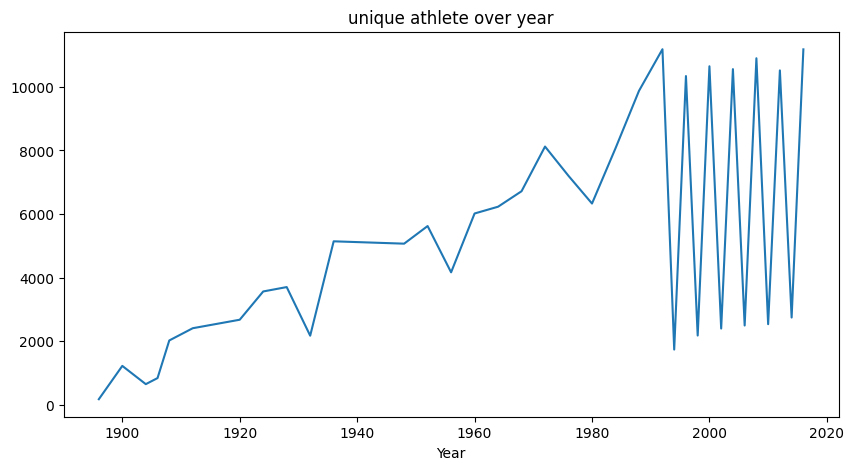

In [20]:
athlete_per_year.plot(figsize=(10,5))
plt.title("unique athlete over year")
ylabel=("No. of athlete")
plt.show()

# Gender Distribution

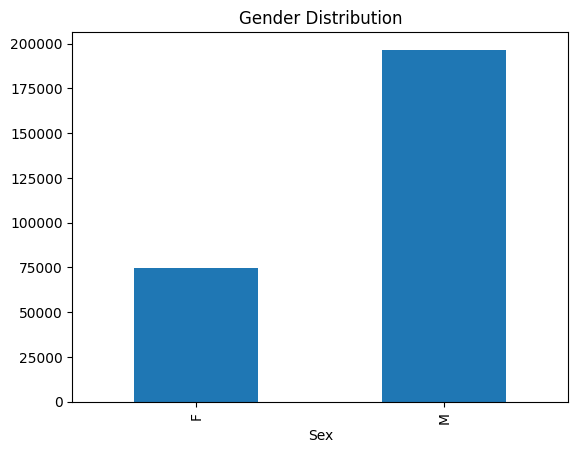

In [21]:
gender_dist=data.groupby(['Sex'])['ID'].count()
gender_dist.plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

# Most Participated Sports

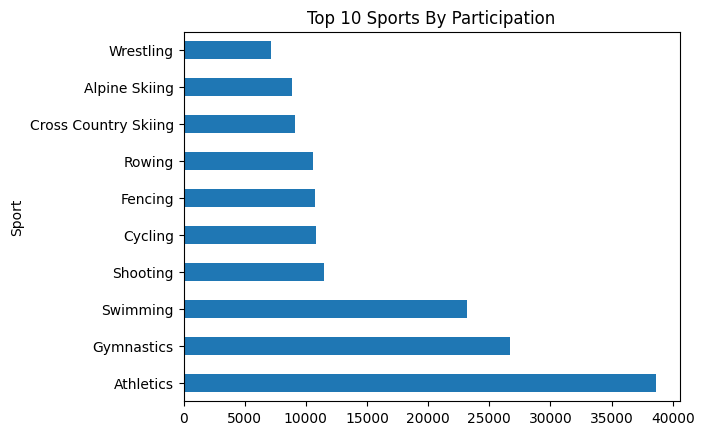

In [22]:
top_sports=data.groupby(['Sport'])['ID'].count().sort_values(ascending=False).head(10)
top_sports.plot(kind='barh')
plt.title("Top 10 Sports By Participation")
plt.show()

# Medal Vs Non Medal Percentage

In [23]:
data['Medal_Binary'] = data['Medal'].replace(
    ['Gold', 'Silver', 'Bronze'], 'Medal'
)
medal_percent = data['Medal_Binary'].value_counts(normalize=True) * 100
medal_percent

Medal_Binary
no medal    85.326207
Medal       14.673793
Name: proportion, dtype: float64

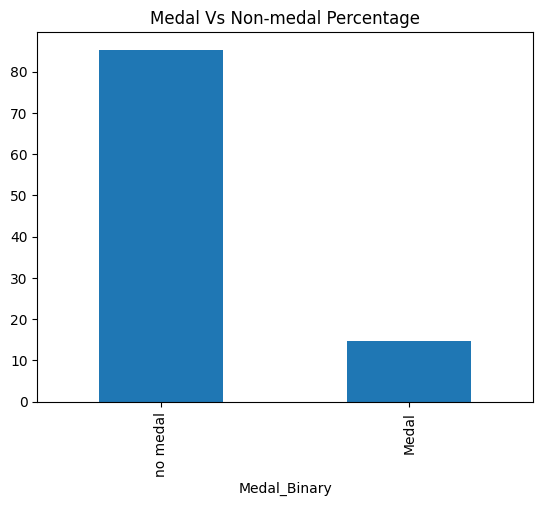

In [24]:
medal_percent.plot(kind='bar')
plt.title("Medal Vs Non-medal Percentage")
plt.show()

# Top 10 countries by athlete count

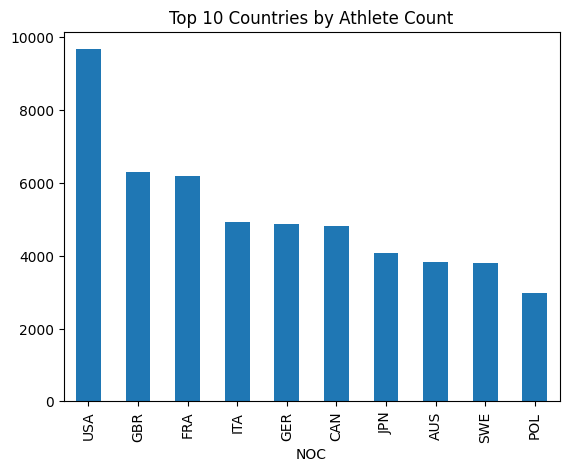

In [25]:
top_countries=data.groupby(['NOC'])['ID'].nunique().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Athlete Count")
plt.show()

In [26]:
data.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,BMI,BMI_group,Medal_Binary
0,1,A Dijiang,M,24.0,180.000000,80.000000,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,no medal,24.691358,"(24.69, 63.902]",no medal
1,2,A Lamusi,M,23.0,170.000000,60.000000,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,no medal,20.761246,"(8.360000000000001, 20.907]",no medal
2,3,Gunnar Nielsen Aaby,M,24.0,177.480339,73.086644,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,no medal,23.202647,"(22.401, 23.232]",no medal
3,4,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,28.714234,"(24.69, 63.902]",Medal
4,5,Christine Jacoba Aaftink,F,21.0,185.000000,82.000000,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,no medal,23.959094,"(23.232, 24.69]",no medal
5,5,Christine Jacoba Aaftink,F,21.0,185.000000,82.000000,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",no medal,23.959094,"(23.232, 24.69]",no medal
6,5,Christine Jacoba Aaftink,F,25.0,185.000000,82.000000,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,no medal,23.959094,"(23.232, 24.69]",no medal
7,5,Christine Jacoba Aaftink,F,25.0,185.000000,82.000000,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",no medal,23.959094,"(23.232, 24.69]",no medal
8,5,Christine Jacoba Aaftink,F,27.0,185.000000,82.000000,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,no medal,23.959094,"(23.232, 24.69]",no medal
9,5,Christine Jacoba Aaftink,F,27.0,185.000000,82.000000,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",no medal,23.959094,"(23.232, 24.69]",no medal


# Medals Efficiency by Country

In [27]:
data['medal_Binary']=data['Medal'].isin(['Gold','Silver','Bronze']).astype(int)
country_eff=data.groupby(['NOC']).agg(
    athletes=('ID',"nunique"),
    medals=("medal_Binary","sum")
)

In [28]:
country_eff['medal_efficiency'] = (
    country_eff['medals'] / country_eff['athletes']
)

In [29]:
top_10_country_eff=country_eff.sort_values(
    'medal_efficiency',
    ascending=False
).head(10)

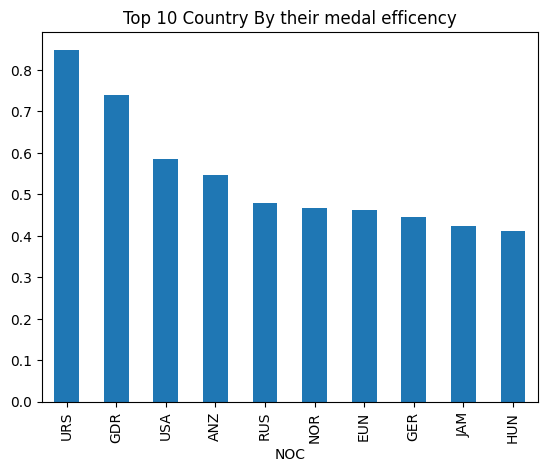

In [30]:
country_eff['medal_efficiency'].sort_values(
    ascending=False
).head(10).plot(kind='bar')
plt.title("Top 10 Country By their medal efficency")
plt.show()

# Sports Producing Most Medal

In [31]:
data.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,BMI,BMI_group,Medal_Binary,medal_Binary
0,1,A Dijiang,M,24.0,180.000000,80.000000,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,no medal,24.691358,"(24.69, 63.902]",no medal,0
1,2,A Lamusi,M,23.0,170.000000,60.000000,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,no medal,20.761246,"(8.360000000000001, 20.907]",no medal,0
2,3,Gunnar Nielsen Aaby,M,24.0,177.480339,73.086644,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,no medal,23.202647,"(22.401, 23.232]",no medal,0
3,4,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,28.714234,"(24.69, 63.902]",Medal,1
4,5,Christine Jacoba Aaftink,F,21.0,185.000000,82.000000,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,no medal,23.959094,"(23.232, 24.69]",no medal,0
5,5,Christine Jacoba Aaftink,F,21.0,185.000000,82.000000,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",no medal,23.959094,"(23.232, 24.69]",no medal,0
6,5,Christine Jacoba Aaftink,F,25.0,185.000000,82.000000,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,no medal,23.959094,"(23.232, 24.69]",no medal,0
7,5,Christine Jacoba Aaftink,F,25.0,185.000000,82.000000,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",no medal,23.959094,"(23.232, 24.69]",no medal,0
8,5,Christine Jacoba Aaftink,F,27.0,185.000000,82.000000,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,no medal,23.959094,"(23.232, 24.69]",no medal,0
9,5,Christine Jacoba Aaftink,F,27.0,185.000000,82.000000,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",no medal,23.959094,"(23.232, 24.69]",no medal,0


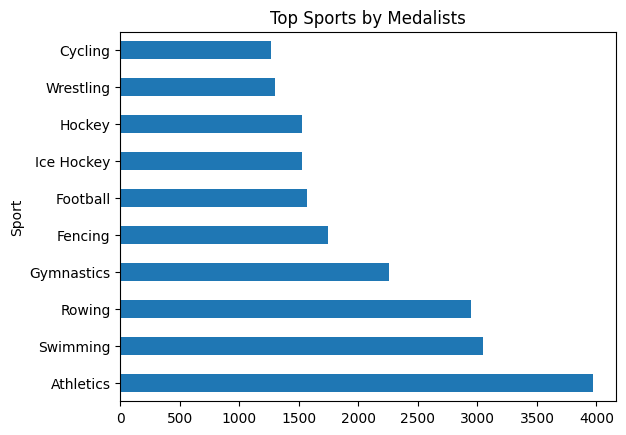

In [32]:
medal_sports = (
    data.groupby('Sport')['medal_Binary']
        .sum()
        .sort_values(ascending=False)
        .head(10)
)
medal_sports.plot(kind='barh')
plt.title("Top Sports by Medalists")
plt.show()

# Age at which athletes win medals most often

In [33]:
data['Age_Group'] = pd.cut(data['Age'], bins=15)

Text(0.5, 1.0, 'medal count at Age Groups ')

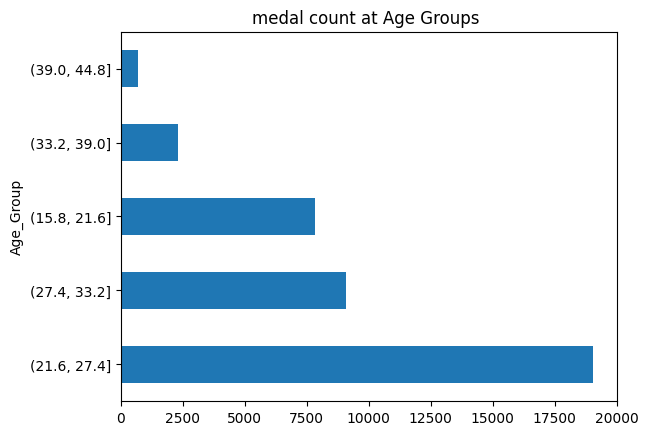

In [34]:
medal_age=data.groupby(['Age_Group'])['medal_Binary'].sum().sort_values(ascending=False).head(5)
medal_age.plot(kind='barh')
plt.title("medal count at Age Groups ")

# Female participation & medal trend over time

In [42]:
female_athlete=data[data['Sex']=='F']


In [40]:
female_trend=female_athlete.groupby('Year').agg(
    participants=('ID','nunique'),
    medals=('medal_Binary','sum')
    
).sort_values('participants',ascending=False).head(5)

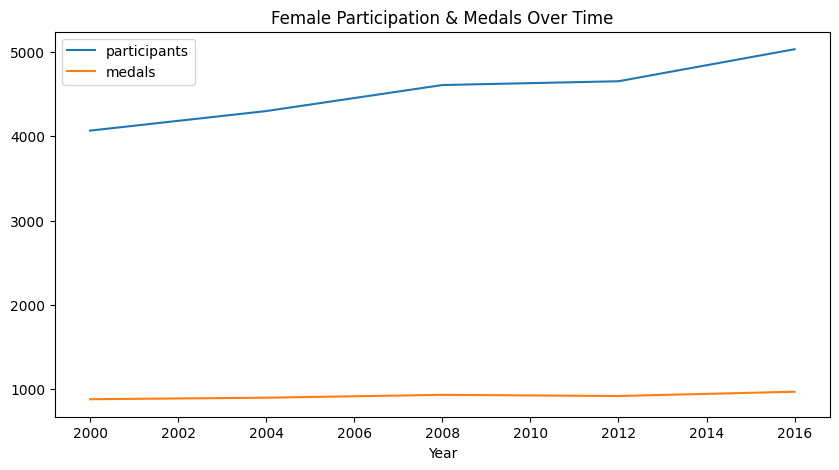

In [41]:
female_trend.plot(figsize=(10,5))
plt.title("Female Participation & Medals Over Time")
plt.show()

# Sports with longest athlete careers

In [47]:
older_medalist=data[(data["Medal"].isin(['Gold','Silver','Bronze'])) & (data['Age']>=35)]
older_medalist['Sport'].value_counts().sort_values(ascending=False).head(10)

Sport
Shooting            526
Equestrianism       475
Sailing             371
Fencing             296
Art Competitions    117
Rowing               98
Archery              91
Athletics            84
Bobsleigh            72
Ice Hockey           57
Name: count, dtype: int64

# Height & Weight vs Medal Success

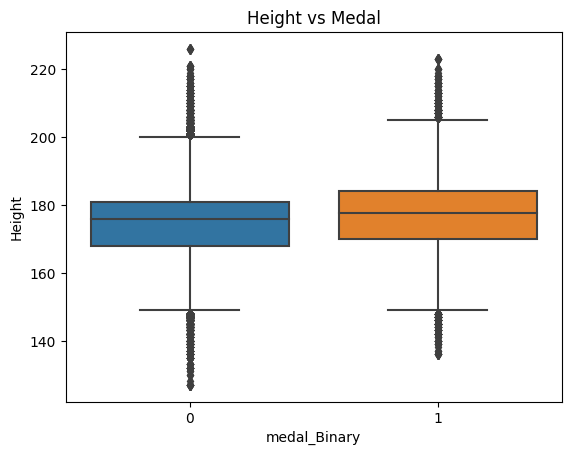

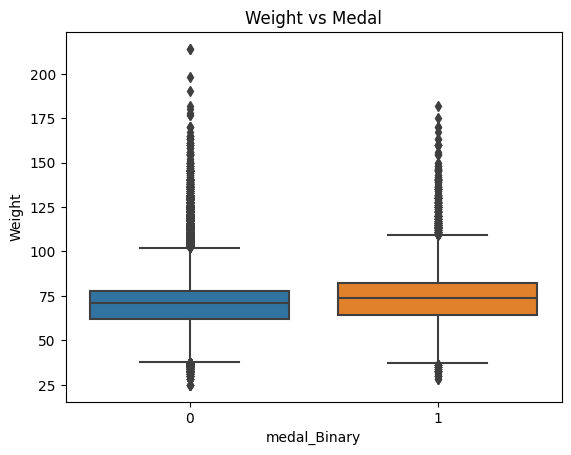

In [50]:
phys_df = data.dropna(subset=['Height', 'Weight'])

sns.boxplot(x=phys_df['medal_Binary'], y=phys_df['Height'])
plt.title("Height vs Medal")
plt.show()

sns.boxplot(x=phys_df['medal_Binary'], y=phys_df['Weight'])
plt.title("Weight vs Medal")
plt.show()
